In [5]:
#25/sep/2026
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sudalairajkumar/covid19-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid19-in-india' dataset.
Path to dataset files: /kaggle/input/covid19-in-india


In [6]:
import os
print(os.listdir(path))

['StatewiseTestingDetails.csv', 'covid_vaccine_statewise.csv', 'covid_19_india.csv']


In [7]:
import pandas as pd
file_path = os.path.join(path, "covid_19_india.csv")
df = pd.read_csv(file_path)

In [8]:
df.head(5)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


In [9]:
print("shape", df.shape)
print("datatype", df.dtypes)
print("Colums", df.columns)

shape (18110, 9)
datatype Sno                          int64
Date                        object
Time                        object
State/UnionTerritory        object
ConfirmedIndianNational     object
ConfirmedForeignNational    object
Cured                        int64
Deaths                       int64
Confirmed                    int64
dtype: object
Colums Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [11]:
df["Date"] = pd.to_datetime(df["Date"])

In [12]:
df["Recovered"] = df["Cured"]

In [13]:
#Create a new column
df["Active"] = df["Confirmed"] - df["Deaths"] - df["Recovered"]
#Check
df.tail(3)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462,334650,444
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812,1685492,545
18109,18110,2021-08-11,8:00 AM,West Bengal,-,-,1506532,18252,1534999,1506532,10215


In [14]:
#Check
df.sample(9)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
8199,8200,2020-11-08,8:00 AM,Sikkim,-,-,3805,76,4195,3805,314
9962,9963,2020-12-28,8:00 AM,Nagaland,-,-,11568,78,11897,11568,251
17525,17526,2021-07-26,8:00 AM,Punjab,-,-,581829,16266,598794,581829,699
7880,7881,2020-10-30,8:00 AM,Odisha,-,-,272038,1297,287099,272038,13764
748,749,2020-04-08,5:00 PM,Gujarat,-,-,25,13,165,25,127
11960,11961,2021-02-22,8:00 AM,Chhattisgarh,-,-,303973,3800,310885,303973,3112
15721,15722,2021-06-06,8:00 AM,Mizoram,-,-,10151,53,13567,10151,3363
8198,8199,2020-11-08,8:00 AM,Rajasthan,-,-,191132,1979,209438,191132,16327
17347,17348,2021-07-21,8:00 AM,Sikkim,-,-,21009,325,23796,21009,2462


In [15]:
#Create our state_level summary
state_data = (
    df.groupby("State/UnionTerritory")
    [["Confirmed", "Deaths", "Recovered", "Active"]]
    .max()
    .reset_index()
)

In [19]:
#create rate
state_data["Recovery_Rate"] = state_data["Recovered"] / state_data["Confirmed"].replace(0,pd.NA)*100
state_data["Death_Rate"] = state_data["Deaths"] / state_data["Confirmed"].replace(0,pd.NA)*100
state_data.head(3)

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
0,Andaman and Nicobar Islands,7548,129,7412,1154,98.198198,1.709062
1,Andhra Pradesh,1985182,13564,1952736,211554,98.365591,0.683262
2,Arunachal Pradesh,50605,248,47821,4465,94.498567,0.490070


In [17]:
state_data.head(3)

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
0,Andaman and Nicobar Islands,7548,129,7412,1154,98.198198,1.709062
1,Andhra Pradesh,1985182,13564,1952736,211554,98.365591,0.683262
2,Arunachal Pradesh,50605,248,47821,4465,94.498567,0.490070


In [20]:
state_data["Recovery_Rate"] = state_data["Recovery_Rate"].round(2)
state_data["Death_Rate"] = state_data["Death_Rate"].round(2)
state_data.head(5)


,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
0,Andaman and Nicobar Islands,7548,129,7412,1154,98.20,1.71
1,Andhra Pradesh,1985182,13564,1952736,211554,98.37,0.68
2,Arunachal Pradesh,50605,248,47821,4465,94.50,0.49
3,Assam,576149,5420,559684,56295,97.14,0.94
4,Bihar,725279,9646,715352,115152,98.63,1.33


In [24]:
#Top 10 states
top10 = (
    state_data
    .sort_values("Confirmed", ascending = False)
    .head(10)
)

/tmp/ipykernel_645/3410994806.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Confirmed')

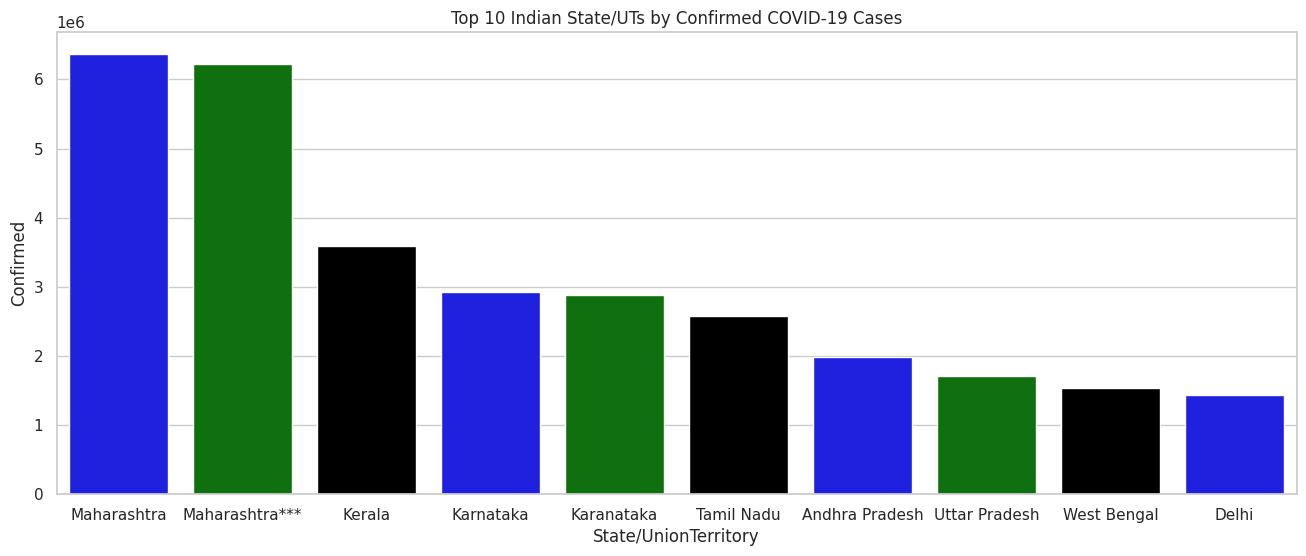

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")
plt.figure(figsize=(16,6))
sns.barplot(
    data = top10,
    x = "State/UnionTerritory",
    y = "Confirmed",
    # color = 'forestgreen'
    palette = ("blue", "green", "black")
)
plt.title("Top 10 Indian State/UTs by Confirmed COVID-19 Cases")
plt.xlabel("State/UnionTerritory")
plt.ylabel("Confirmed")


/tmp/ipykernel_645/1208923261.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Death')

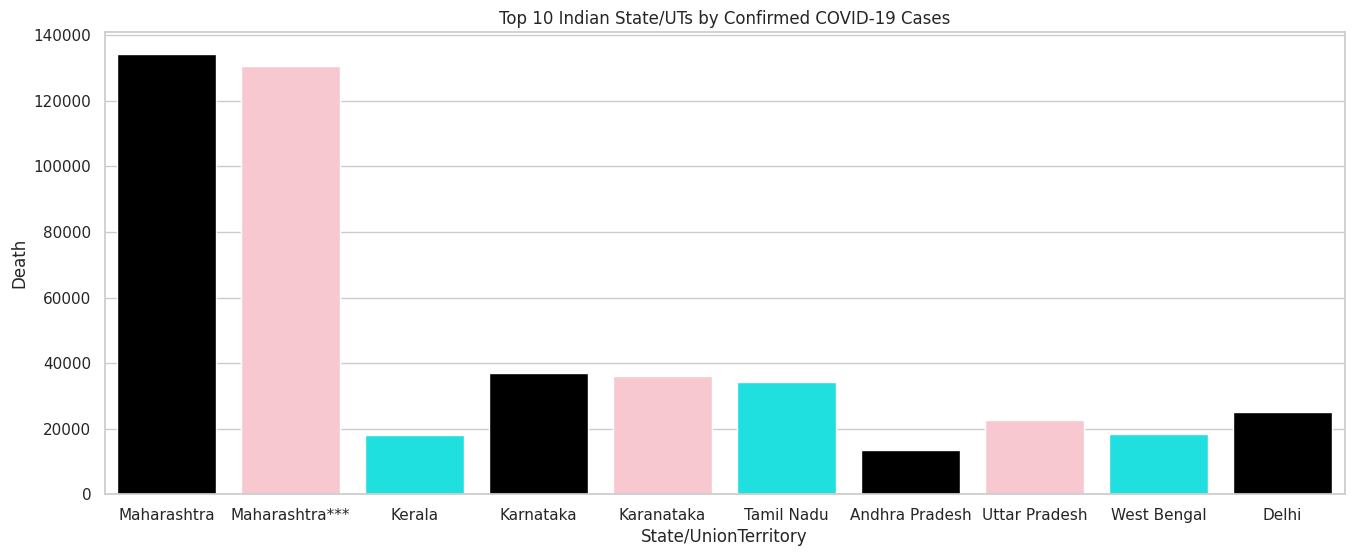

In [35]:
#Top 10 states by deaths

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")
plt.figure(figsize=(16,6))

sns.barplot(
    data = top10,
    x = "State/UnionTerritory",
    y = "Deaths",
    # color = 'forestgreen'
    palette = ("black", "pink", "cyan")
)
plt.title("Top 10 Indian State/UTs by Confirmed COVID-19 Cases")
plt.xlabel("State/UnionTerritory")
plt.ylabel("Death")


/tmp/ipykernel_645/3727267954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Death_Rate')

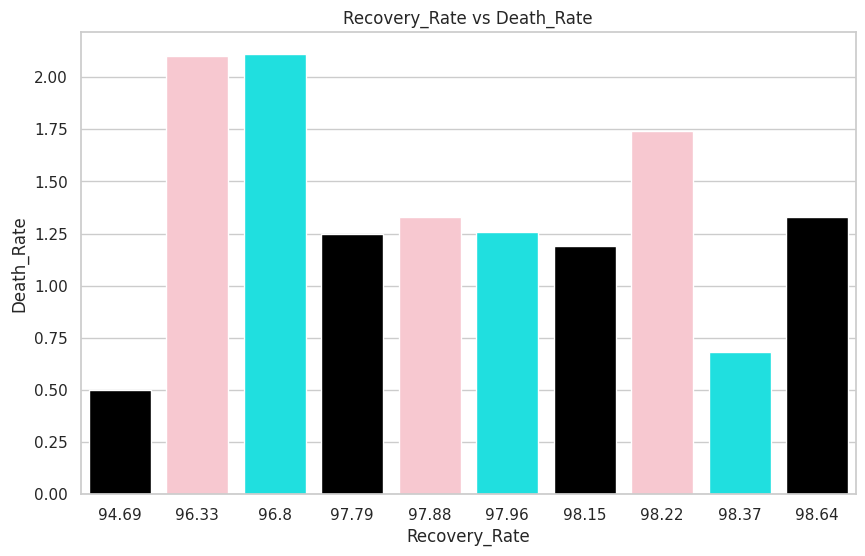

In [42]:
#Recovery_Rate vs Death_Rate
rate_data = state_data.sort_values("Recovery_Rate", ascending = False).head(10)
plt.figure(figsize=(10,6))

sns.barplot(
    data = top10,
    x = "Recovery_Rate",
    y = "Death_Rate",
    # color = 'forestgreen'
    palette = ("black", "pink", "cyan")
)
plt.title("Recovery_Rate vs Death_Rate")
plt.xlabel("Recovery_Rate")
plt.ylabel("Death_Rate")

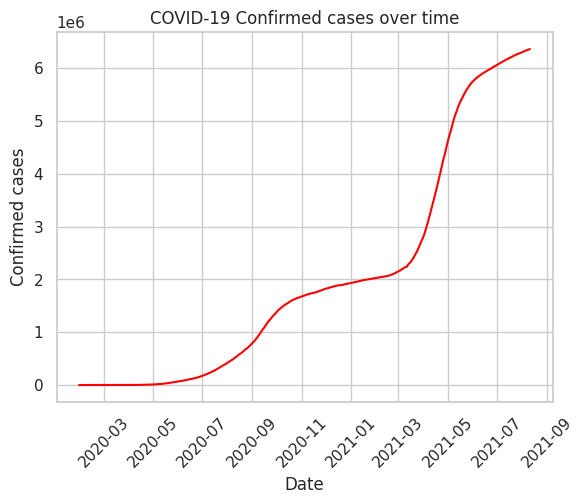

In [44]:
daily_cases = (
    df.groupby("Date")
    ["Confirmed"]
    .max()
    .reset_index()
)
sns.lineplot(
    data = daily_cases,
    x = "Date",
    y = "Confirmed",
    color = "red"
)
plt.title("COVID-19 Confirmed cases over time")
plt.xlabel("Date")
plt.ylabel("Confirmed cases")
plt.xticks(rotation = 45)
plt.show()
